# Dataset 1 – Hand-Written Digits Recognition
**Implementation:** Vishal Hanuman  
**Algorithms:** k-NN (HW1) · Random Forest (HW3)  
**Evaluation:** Stratified 10-fold CV · Accuracy · Macro F1

In [1]:
import sys, os, subprocess

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    subprocess.run(['git', 'clone', f'https://github.com/vishalhanuman14/classical-ml-benchmark.git'], check=True)
    os.chdir('classical-ml-benchmark')

if '.' not in sys.path:
    sys.path.insert(0, '.')


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets

from algorithms.vishal import knn, random_forest, utils

# ── Load ──────────────────────────────────────────────────────────────────
digits = datasets.load_digits(return_X_y=True)
X_raw, y = digits[0], digits[1].astype(str)

# Normalize (fit on full set – CV loop below re-normalizes per fold)
X_full, _ = utils.normalize(X_raw, X_raw)

print(f"Instances: {len(y)}, Features: {X_full.shape[1]}, Classes: {np.unique(y)}")


Instances: 1797, Features: 64, Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


## k-NN – Hyperparameter Sweep (k)

In [3]:
K_VALUES = [1, 3, 5, 7, 11, 15, 21, 31]
knn_results = {}

for k in K_VALUES:
    def model_fn(Xtr, ytr, Xte):
        Xtr_n, Xte_n = utils.normalize(Xtr, Xte)
        return knn.predict(Xtr_n, ytr, Xte_n, k)

    acc, f1 = utils.cross_validate(model_fn, X_raw, y, pos_label=y[0])
    knn_results[k] = (acc, f1)
    print(f"k={k:>3}  acc={acc:.4f}  f1={f1:.4f}")


k=  1  acc=0.9889  f1=0.9888
k=  3  acc=0.9877  f1=0.9878
k=  5  acc=0.9889  f1=0.9889
k=  7  acc=0.9866  f1=0.9865
k= 11  acc=0.9827  f1=0.9826
k= 15  acc=0.9799  f1=0.9799
k= 21  acc=0.9733  f1=0.9731
k= 31  acc=0.9673  f1=0.9668


Best k = 5  (acc=0.9889, f1=0.9889)


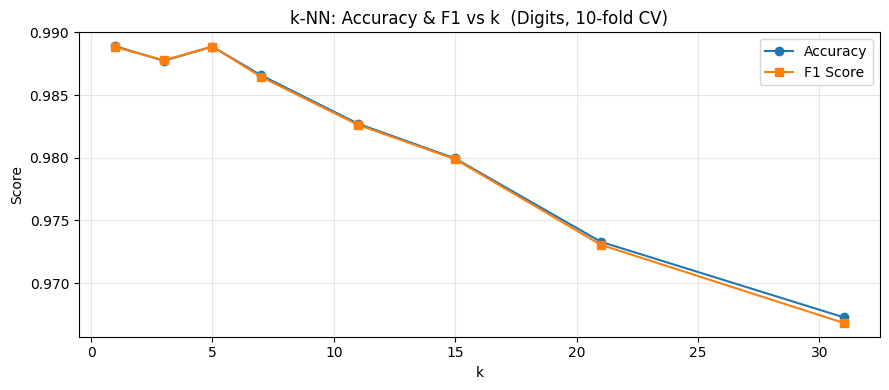

In [4]:
best_k = max(knn_results, key=lambda k: knn_results[k][1])
print(f"Best k = {best_k}  (acc={knn_results[best_k][0]:.4f}, f1={knn_results[best_k][1]:.4f})")

ks   = list(knn_results.keys())
accs = [knn_results[k][0] for k in ks]
f1s  = [knn_results[k][1] for k in ks]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, accs, '-o', label='Accuracy')
ax.plot(ks, f1s,  '-s', label='F1 Score')
ax.set_xlabel('k'); ax.set_ylabel('Score')
ax.set_title('k-NN: Accuracy & F1 vs k  (Digits, 10-fold CV)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/digits_knn_k_sweep.png', dpi=150)
plt.show()


## Random Forest – Hyperparameter Sweep (ntree)

In [5]:
feature_types = ['num'] * X_full.shape[1]
NTREE_VALUES  = [5, 10, 20, 30, 50, 75, 100, 150]
rf_results    = {}

for nt in NTREE_VALUES:
    def model_fn(Xtr, ytr, Xte, nt=nt):
        trees = random_forest.train(Xtr, ytr, feature_types, nt)
        return random_forest.predict(trees, Xte)

    acc, f1 = utils.cross_validate(model_fn, X_full, y, pos_label=y[0])
    rf_results[nt] = (acc, f1)
    print(f"ntree={nt:>4}  acc={acc:.4f}  f1={f1:.4f}")


ntree=   5  acc=0.8836  f1=0.8831
ntree=  10  acc=0.9306  f1=0.9301
ntree=  20  acc=0.9539  f1=0.9536
ntree=  30  acc=0.9660  f1=0.9658
ntree=  50  acc=0.9634  f1=0.9634
ntree=  75  acc=0.9727  f1=0.9727
ntree= 100  acc=0.9660  f1=0.9659
ntree= 150  acc=0.9728  f1=0.9727


Best ntree = 150  (acc=0.9728, f1=0.9727)


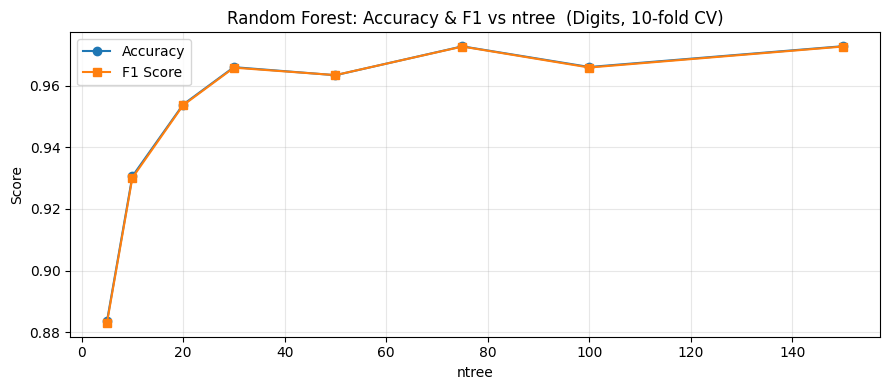

In [6]:
best_nt = max(rf_results, key=lambda n: rf_results[n][1])
print(f"Best ntree = {best_nt}  (acc={rf_results[best_nt][0]:.4f}, f1={rf_results[best_nt][1]:.4f})")

nts  = list(rf_results.keys())
accs = [rf_results[n][0] for n in nts]
f1s  = [rf_results[n][1] for n in nts]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(nts, accs, '-o', label='Accuracy')
ax.plot(nts, f1s,  '-s', label='F1 Score')
ax.set_xlabel('ntree'); ax.set_ylabel('Score')
ax.set_title('Random Forest: Accuracy & F1 vs ntree  (Digits, 10-fold CV)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/digits_rf_ntree_sweep.png', dpi=150)
plt.show()


## Summary Table – Digits

In [7]:
print(f"{'Algorithm':<20} {'Best HP':<12} {'Accuracy':>10} {'F1 Score':>10}")
print('-' * 56)
print(f"{'k-NN':<20} {'k='+str(best_k):<12} {knn_results[best_k][0]:>10.4f} {knn_results[best_k][1]:>10.4f}")
print(f"{'Random Forest':<20} {'ntree='+str(best_nt):<12} {rf_results[best_nt][0]:>10.4f} {rf_results[best_nt][1]:>10.4f}")


Algorithm            Best HP        Accuracy   F1 Score
--------------------------------------------------------
k-NN                 k=5              0.9889     0.9889
Random Forest        ntree=150        0.9728     0.9727
